In [181]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (

    mean_absolute_error,

    mean_squared_error,

    r2_score

)

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.vector_ar.var_model import VAR

In [182]:
df = pd.read_csv("shimla_urban.csv")
df.head()

,YEAR,MO,DY,HR,ALLSKY_SFC_SW_DWN,T2M,PRECTOTCORR,WS10M,PS,RH2M,SZA,ALLSKY_KT
0,2019,1,1,0,0.0,7.58,0.0,2.43,91.76,46.46,90.0,-999.0
1,2019,1,1,1,0.0,7.72,0.0,2.49,91.73,43.62,90.0,-999.0
2,2019,1,1,2,0.0,7.86,0.0,2.38,91.68,40.70,90.0,-999.0
3,2019,1,1,3,0.0,8.28,0.0,2.25,91.63,37.12,90.0,-999.0
4,2019,1,1,4,0.0,9.05,0.0,1.97,91.61,33.69,90.0,-999.0


In [183]:
print("Shimla :", df.shape)


Shimla : (61392, 12)


In [184]:
# df.isnull().sum()
(df == -999).sum()

YEAR                     0
MO                       0
DY                       0
HR                       0
ALLSKY_SFC_SW_DWN        0
T2M                      0
PRECTOTCORR              0
WS10M                    0
PS                       0
RH2M                     0
SZA                      0
ALLSKY_KT            29797
dtype: int64

In [185]:
df.replace(-999, np.nan, inplace = True)
df.dropna(inplace = True)

In [186]:
df["datetime"] = pd.to_datetime(
    df[["YEAR", "MO", "DY", "HR"]]
    .rename(columns={
        "YEAR":"year",
        "MO":"month",
        "DY":"day",
        "HR":"hour"
    })
)

In [187]:
df = df.sort_values("datetime")
df.set_index("datetime", inplace=True)
df.head()

,YEAR,MO,DY,HR,ALLSKY_SFC_SW_DWN,T2M,PRECTOTCORR,WS10M,PS,RH2M,SZA,ALLSKY_KT
datetime,,,,,,,,,,,,
2019-01-01 07:00:00,2019,1,1,7,67.90,9.93,0.0,1.15,91.77,30.85,83.27,0.41
2019-01-01 08:00:00,2019,1,1,8,204.85,12.57,0.0,1.03,91.84,46.30,73.15,0.50
2019-01-01 09:00:00,2019,1,1,9,279.30,15.72,0.0,1.25,91.87,28.05,64.53,0.46
2019-01-01 10:00:00,2019,1,1,10,407.30,16.92,0.0,2.12,91.84,27.12,58.20,0.55
2019-01-01 11:00:00,2019,1,1,11,471.95,16.98,0.0,2.57,91.77,28.59,54.96,0.58


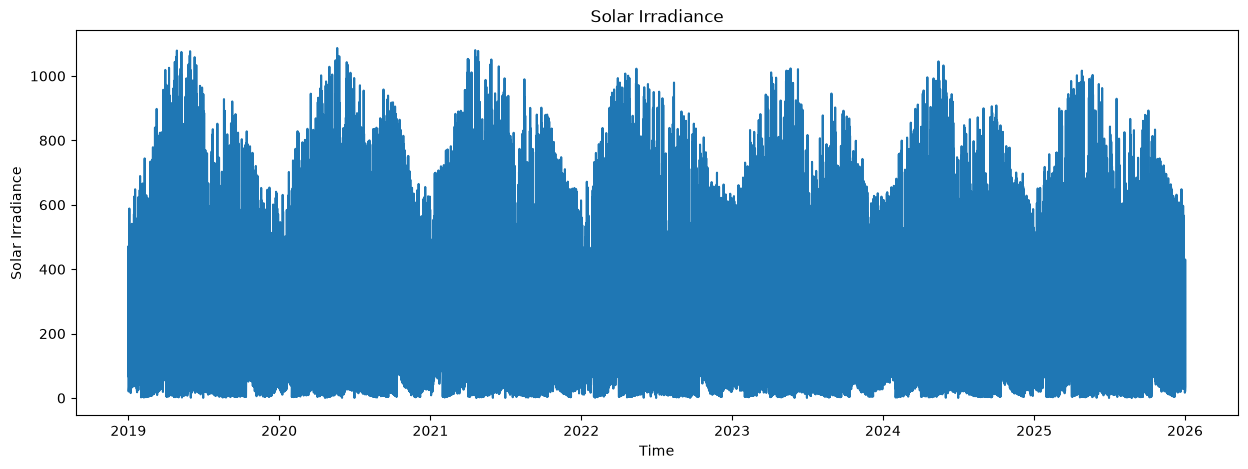

In [188]:
y = df["ALLSKY_SFC_SW_DWN"]
plt.figure(figsize=(15, 5))
plt.plot(y)
plt.title("Solar Irradiance")
plt.xlabel("Time")
plt.ylabel("Solar Irradiance")
plt.show()

In [189]:
train_size = int(len(y)*0.8)
train = y[:train_size]
test = y[train_size:]

print(len(train))
print(len(test))

25276
6319


In [190]:
model = ARIMA(
    train,
    order=(5, 1, 0)
)

model_fit = model.fit()
print(model_fit.summary)

/Users/ak/Desktop/projects/DL_wind_solar_forecast/tf_env/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/ak/Desktop/projects/DL_wind_solar_forecast/tf_env/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/ak/Desktop/projects/DL_wind_solar_forecast/tf_env/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


<bound method SARIMAXResults.summary of <statsmodels.tsa.arima.model.ARIMAResults object at 0x117990e60>>


In [191]:
arima_pred = model_fit.forecast(
    steps=len(test)
)
print(arima_pred.head())

25276    580.758961
25277    492.113696
25278    395.147790
25279    307.121801
25280    254.875954
Name: predicted_mean, dtype: float64


/Users/ak/Desktop/projects/DL_wind_solar_forecast/tf_env/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/Users/ak/Desktop/projects/DL_wind_solar_forecast/tf_env/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [192]:
mae = mean_absolute_error(
    test,
    arima_pred
)

rmse = np.sqrt(
    mean_squared_error(
        test,
        arima_pred
    )
)

r2 = r2_score(
    test,
    arima_pred
)

print("ARIMA Results")
print("MAE :", mae)
print("RMSE :", rmse)
print("R² :", r2)

ARIMA Results
MAE : 219.77907782989593
RMSE : 254.5011375704705
R² : -0.04421566851968439


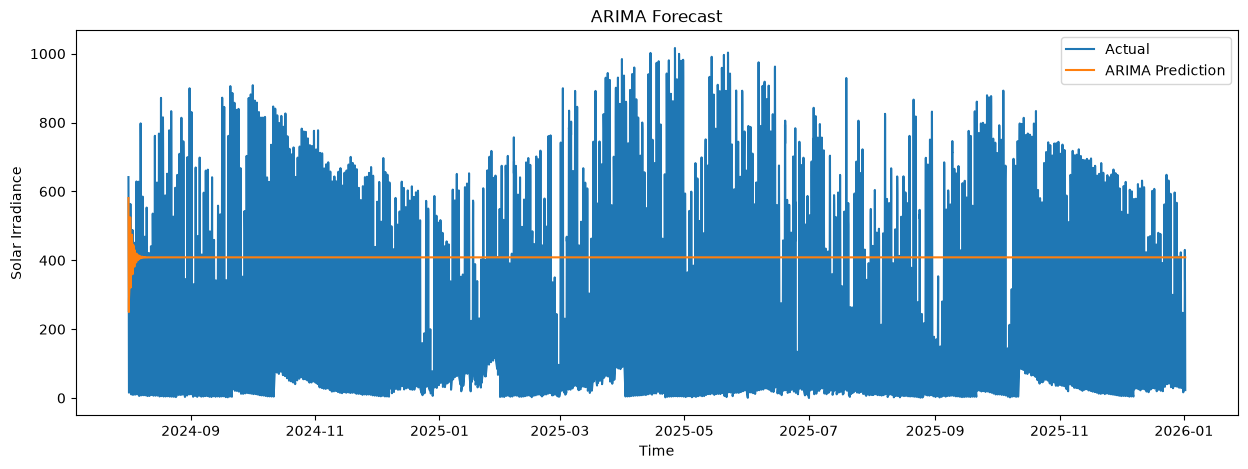

In [193]:
plt.figure(figsize=(15,5))

plt.plot(
    test.index,
    test,
    label="Actual"
)

plt.plot(
    test.index,
    arima_pred,
    label="ARIMA Prediction"
)

plt.title("ARIMA Forecast")

plt.xlabel("Time")

plt.ylabel("Solar Irradiance")

plt.legend()

plt.show()

In [194]:
model = ARIMA(
    train,
    order=(1, 1, 1)
)

model_fit = model.fit()
print(model_fit.summary)

arima_pred = model_fit.forecast(
    steps=len(test)
)
print(arima_pred.head())


mae = mean_absolute_error(
    test,
    arima_pred
)

rmse = np.sqrt(
    mean_squared_error(
        test,
        arima_pred
    )
)

r2 = r2_score(
    test,
    arima_pred
)

print("ARIMA Results")
print("MAE :", mae)
print("RMSE :", rmse)
print("R² :", r2)

/Users/ak/Desktop/projects/DL_wind_solar_forecast/tf_env/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/ak/Desktop/projects/DL_wind_solar_forecast/tf_env/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/ak/Desktop/projects/DL_wind_solar_forecast/tf_env/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


<bound method SARIMAXResults.summary of <statsmodels.tsa.arima.model.ARIMAResults object at 0x117990410>>
25276    634.958734
25277    638.683308
25278    641.126186
25279    642.728423
25280    643.779301
Name: predicted_mean, dtype: float64
ARIMA Results
MAE : 321.8774006543172
RMSE : 381.9048879145433
R² : -1.3513711397537844


/Users/ak/Desktop/projects/DL_wind_solar_forecast/tf_env/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/Users/ak/Desktop/projects/DL_wind_solar_forecast/tf_env/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [195]:
model = ARIMA(
    train,
    order=(5, 1, 5)
)

model_fit = model.fit()
print(model_fit.summary)

arima_pred = model_fit.forecast(
    steps=len(test)
)
print(arima_pred.head())


mae = mean_absolute_error(
    test,
    arima_pred
)

rmse = np.sqrt(
    mean_squared_error(
        test,
        arima_pred
    )
)

r2 = r2_score(
    test,
    arima_pred
)

print("ARIMA Results")
print("MAE :", mae)
print("RMSE :", rmse)
print("R² :", r2)

/Users/ak/Desktop/projects/DL_wind_solar_forecast/tf_env/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/ak/Desktop/projects/DL_wind_solar_forecast/tf_env/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/ak/Desktop/projects/DL_wind_solar_forecast/tf_env/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/ak/Desktop/projects/DL_wind_solar_forecast/tf_env/lib/python3.12/site-packages/statsmodels/tsa/statespace

<bound method SARIMAXResults.summary of <statsmodels.tsa.arima.model.ARIMAResults object at 0x119170e90>>
25276    578.839942
25277    473.968809
25278    345.396337
25279    224.741068
25280    136.930329
Name: predicted_mean, dtype: float64
ARIMA Results
MAE : 213.94126102645347
RMSE : 249.5136544205364
R² : -0.0036895067527129566


/Users/ak/Desktop/projects/DL_wind_solar_forecast/tf_env/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/Users/ak/Desktop/projects/DL_wind_solar_forecast/tf_env/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [196]:
model = ARIMA(
    train,
    order=(10, 1, 10)
)

model_fit = model.fit()
print(model_fit.summary)

arima_pred = model_fit.forecast(
    steps=len(test)
)
print(arima_pred.head())


mae = mean_absolute_error(
    test,
    arima_pred
)

rmse = np.sqrt(
    mean_squared_error(
        test,
        arima_pred
    )
)

r2 = r2_score(
    test,
    arima_pred
)

print("ARIMA Results")
print("MAE :", mae)
print("RMSE :", rmse)
print("R² :", r2)

/Users/ak/Desktop/projects/DL_wind_solar_forecast/tf_env/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/ak/Desktop/projects/DL_wind_solar_forecast/tf_env/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/ak/Desktop/projects/DL_wind_solar_forecast/tf_env/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/ak/Desktop/projects/DL_wind_solar_forecast/tf_env/lib/python3.12/site-packages/statsmodels/tsa/statespace

<bound method SARIMAXResults.summary of <statsmodels.tsa.arima.model.ARIMAResults object at 0x1191395e0>>
25276    581.465385
25277    487.384978
25278    364.770999
25279    235.427087
25280    134.771826
Name: predicted_mean, dtype: float64
ARIMA Results
MAE : 214.02164621482396
RMSE : 249.4446708545583
R² : -0.003134599164410945


/Users/ak/Desktop/projects/DL_wind_solar_forecast/tf_env/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/Users/ak/Desktop/projects/DL_wind_solar_forecast/tf_env/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [197]:
# <------------------------------------- ARIMAX(1h) ------------------------------------------------>

In [198]:
forecast_horizon = 1

df["target"] = df["ALLSKY_SFC_SW_DWN"].shift(-forecast_horizon)

df.dropna(inplace=True)

y = df["target"]

train_size = int(len(y)*0.8)
train = y[:train_size]
test = y[train_size:]

print(len(train))
print(len(test))


25275
6319


In [199]:
model = ARIMA(
    train,
    order=(5, 1, 5)
)

model_fit = model.fit()
print(model_fit.summary)

arima_pred = model_fit.forecast(
    steps=len(test)
)
print(arima_pred.head())


mae = mean_absolute_error(
    test,
    arima_pred
)

rmse = np.sqrt(
    mean_squared_error(
        test,
        arima_pred
    )
)

r2 = r2_score(
    test,
    arima_pred
)

print("ARIMA Results")
print("MAE :", mae)
print("RMSE :", rmse)
print("R² :", r2)

/Users/ak/Desktop/projects/DL_wind_solar_forecast/tf_env/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/ak/Desktop/projects/DL_wind_solar_forecast/tf_env/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/ak/Desktop/projects/DL_wind_solar_forecast/tf_env/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/ak/Desktop/projects/DL_wind_solar_forecast/tf_env/lib/python3.12/site-packages/statsmodels/tsa/statespace

<bound method SARIMAXResults.summary of <statsmodels.tsa.arima.model.ARIMAResults object at 0x119138d70>>
25275    579.073399
25276    474.378604
25277    345.833475
25278    225.285223
25279    137.406275
Name: predicted_mean, dtype: float64
ARIMA Results
MAE : 213.93849216084118
RMSE : 249.50771512513592
R² : -0.003641724698171478


/Users/ak/Desktop/projects/DL_wind_solar_forecast/tf_env/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/Users/ak/Desktop/projects/DL_wind_solar_forecast/tf_env/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [200]:
results = []

results.append({
    "MODEL":"ARIMA",
    "Horizon": "1h",
    "MAE": mae,
    "RMSE": rmse,
    "R2": r2
})

In [201]:
# <------------------------------------- ARIMAX(6h) ------------------------------------------------>

In [202]:
forecast_horizon = 6

df["target"] = df["ALLSKY_SFC_SW_DWN"].shift(-forecast_horizon)

df.dropna(inplace=True)

y = df["target"]


train_size = int(len(y)*0.8)
train = y[:train_size]
test = y[train_size:]

print(len(train))
print(len(test))


25270
6318


In [203]:
model = ARIMA(
    train,
    order=(5, 1, 5)
)

model_fit = model.fit()
print(model_fit.summary)

arima_pred = model_fit.forecast(
    steps=len(test)
)
print(arima_pred.head())


mae = mean_absolute_error(
    test,
    arima_pred
)

rmse = np.sqrt(
    mean_squared_error(
        test,
        arima_pred
    )
)

r2 = r2_score(
    test,
    arima_pred
)

print("ARIMA Results")
print("MAE :", mae)
print("RMSE :", rmse)
print("R² :", r2)

results.append({
    "MODEL":"ARIMA",
    "Horizon": "6h",
    "MAE": mae,
    "RMSE": rmse,
    "R2": r2
})

/Users/ak/Desktop/projects/DL_wind_solar_forecast/tf_env/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/ak/Desktop/projects/DL_wind_solar_forecast/tf_env/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/ak/Desktop/projects/DL_wind_solar_forecast/tf_env/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/ak/Desktop/projects/DL_wind_solar_forecast/tf_env/lib/python3.12/site-packages/statsmodels/tsa/statespace

<bound method SARIMAXResults.summary of <statsmodels.tsa.arima.model.ARIMAResults object at 0x11ad90620>>
25270    579.078189
25271    474.466578
25272    346.202071
25273    226.027254
25274    138.436605
Name: predicted_mean, dtype: float64
ARIMA Results
MAE : 213.9179547739285
RMSE : 249.47519920761738
R² : -0.003505410412767418


/Users/ak/Desktop/projects/DL_wind_solar_forecast/tf_env/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/Users/ak/Desktop/projects/DL_wind_solar_forecast/tf_env/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [204]:
# <------------------------------------- ARIMAX(12h) ------------------------------------------------>

In [205]:
forecast_horizon = 12

df["target"] = df["ALLSKY_SFC_SW_DWN"].shift(-forecast_horizon)

df.dropna(inplace=True)

y = df["target"]


train_size = int(len(y)*0.8)
train = y[:train_size]
test = y[train_size:]

print(len(train))
print(len(test))



25260
6316


In [206]:
model = ARIMA(
    train,
    order=(5, 1, 5)
)

model_fit = model.fit()
print(model_fit.summary)

arima_pred = model_fit.forecast(
    steps=len(test)
)
print(arima_pred.head())


mae = mean_absolute_error(
    test,
    arima_pred
)

rmse = np.sqrt(
    mean_squared_error(
        test,
        arima_pred
    )
)

r2 = r2_score(
    test,
    arima_pred
)

print("ARIMA Results")
print("MAE :", mae)
print("RMSE :", rmse)
print("R² :", r2)

results.append({
    "MODEL":"ARIMA",
    "Horizon": "12h",
    "MAE": mae,
    "RMSE": rmse,
    "R2": r2
})

/Users/ak/Desktop/projects/DL_wind_solar_forecast/tf_env/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/ak/Desktop/projects/DL_wind_solar_forecast/tf_env/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/ak/Desktop/projects/DL_wind_solar_forecast/tf_env/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/ak/Desktop/projects/DL_wind_solar_forecast/tf_env/lib/python3.12/site-packages/statsmodels/tsa/statespace

<bound method SARIMAXResults.summary of <statsmodels.tsa.arima.model.ARIMAResults object at 0x1196c0170>>
25260    435.498563
25261    557.972027
25262    620.851123
25263    615.057558
25264    545.986692
Name: predicted_mean, dtype: float64
ARIMA Results
MAE : 213.96292732487993
RMSE : 249.99623081257744
R² : -0.007186339833977762


/Users/ak/Desktop/projects/DL_wind_solar_forecast/tf_env/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/Users/ak/Desktop/projects/DL_wind_solar_forecast/tf_env/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [207]:
# <------------------------------------- ARIMAX(24h) ------------------------------------------------>

In [208]:
forecast_horizon = 24

df["target"] = df["ALLSKY_SFC_SW_DWN"].shift(-forecast_horizon)

df.dropna(inplace=True)

y = df["target"]


train_size = int(len(y)*0.8)
train = y[:train_size]
test = y[train_size:]

print(len(train))
print(len(test))



25241
6311


In [209]:
model = ARIMA(
    train,
    order=(5, 1, 5)
)

model_fit = model.fit()
print(model_fit.summary)

arima_pred = model_fit.forecast(
    steps=len(test)
)
print(arima_pred.head())


mae = mean_absolute_error(
    test,
    arima_pred
)

rmse = np.sqrt(
    mean_squared_error(
        test,
        arima_pred
    )
)

r2 = r2_score(
    test,
    arima_pred
)

print("ARIMA Results")
print("MAE :", mae)
print("RMSE :", rmse)
print("R² :", r2)

results.append({
    "MODEL":"ARIMA",
    "Horizon": "24h",
    "MAE": mae,
    "RMSE": rmse,
    "R2": r2
})

/Users/ak/Desktop/projects/DL_wind_solar_forecast/tf_env/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/ak/Desktop/projects/DL_wind_solar_forecast/tf_env/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/ak/Desktop/projects/DL_wind_solar_forecast/tf_env/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/ak/Desktop/projects/DL_wind_solar_forecast/tf_env/lib/python3.12/site-packages/statsmodels/tsa/statespace

<bound method SARIMAXResults.summary of <statsmodels.tsa.arima.model.ARIMAResults object at 0x11adaa750>>
25241    332.015779
25242    222.419714
25243    152.638344
25244    133.250956
25245    170.588970
Name: predicted_mean, dtype: float64
ARIMA Results
MAE : 214.80848450003072
RMSE : 249.22469930391384
R² : -0.000625738010111565


/Users/ak/Desktop/projects/DL_wind_solar_forecast/tf_env/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/Users/ak/Desktop/projects/DL_wind_solar_forecast/tf_env/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [210]:
# <------------------------------------- SARIMAX ------------------------------------------------>

In [211]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

train_size = int(len(y) * 0.8)

train = y.iloc[:train_size]

test = y.iloc[train_size:]

model = SARIMAX(
    train,
    order=(5,1,0),
    seasonal_order=(1,1,1,24),
    enforce_stationarity=False,
    enforce_invertibility=False
)

model_fit = model.fit(disp=False)

sarima_pred = model_fit.forecast(
    steps=len(test)
)

/Users/ak/Desktop/projects/DL_wind_solar_forecast/tf_env/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/ak/Desktop/projects/DL_wind_solar_forecast/tf_env/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/ak/Desktop/projects/DL_wind_solar_forecast/tf_env/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/Users/ak/Desktop/projects/DL_wind_solar_forecast/tf_env/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: Fut

In [212]:
mae = mean_absolute_error(test, sarima_pred)

rmse = np.sqrt(mean_squared_error(test, sarima_pred))

r2 = r2_score(test, sarima_pred)

print("SARIMA")
print("MAE :", mae)
print("RMSE :", rmse)
print("R² :", r2)

SARIMA
MAE : 219.23810818905602
RMSE : 254.0921906908956
R² : -0.04009292782043272


In [213]:
forecast_horizon = 1

df["target"] = df["ALLSKY_SFC_SW_DWN"].shift(-forecast_horizon)
df = df.dropna().copy()

y = df["target"]

train_size = int(len(y)*0.8)

train = y.iloc[:train_size]
test = y.iloc[train_size:]

model = SARIMAX(
    train,
    order=(5,1,0),
    seasonal_order=(1,1,1,24),
    enforce_stationarity=False,
    enforce_invertibility=False
)

model_fit = model.fit(disp=False)

sarima_pred = model_fit.forecast(
    steps=len(test)
)

mae = mean_absolute_error(test, sarima_pred)
rmse = np.sqrt(mean_squared_error(test, sarima_pred))
r2 = r2_score(test, sarima_pred)

print("1 Hour")
print(mae, rmse, r2)

results.append({
    "MODEL":"SARIMAX",
    "Horizon": "1h",
    "MAE": mae,
    "RMSE": rmse,
    "R2": r2
})

/Users/ak/Desktop/projects/DL_wind_solar_forecast/tf_env/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/ak/Desktop/projects/DL_wind_solar_forecast/tf_env/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/ak/Desktop/projects/DL_wind_solar_forecast/tf_env/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/Users/ak/Desktop/projects/DL_wind_solar_forecast/tf_env/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: Fut

1 Hour
505.3624812101649 594.330058968746 -4.684740321476304


In [214]:
forecast_horizon = 6

df["target"] = df["ALLSKY_SFC_SW_DWN"].shift(-forecast_horizon)
df = df.dropna().copy()

y = df["target"]

train_size = int(len(y)*0.8)

train = y.iloc[:train_size]
test = y.iloc[train_size:]

model = SARIMAX(
    train,
    order=(5,1,0),
    seasonal_order=(1,1,1,24),
    enforce_stationarity=False,
    enforce_invertibility=False
)

model_fit = model.fit(disp=False)

sarima_pred = model_fit.forecast(
    steps=len(test)
)

mae = mean_absolute_error(test, sarima_pred)
rmse = np.sqrt(mean_squared_error(test, sarima_pred))
r2 = r2_score(test, sarima_pred)

print("1 Hour")
print(mae, rmse, r2)

results.append({
    "MODEL":"SARIMAX",
    "Horizon": "6h",
    "MAE": mae,
    "RMSE": rmse,
    "R2": r2
})

/Users/ak/Desktop/projects/DL_wind_solar_forecast/tf_env/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/ak/Desktop/projects/DL_wind_solar_forecast/tf_env/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/ak/Desktop/projects/DL_wind_solar_forecast/tf_env/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/Users/ak/Desktop/projects/DL_wind_solar_forecast/tf_env/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: Fut

1 Hour
388.37137079311253 470.5434327754182 -2.5632481005111036


In [215]:
forecast_horizon = 12

df["target"] = df["ALLSKY_SFC_SW_DWN"].shift(-forecast_horizon)
df = df.dropna().copy()

y = df["target"]

train_size = int(len(y)*0.8)

train = y.iloc[:train_size]
test = y.iloc[train_size:]

model = SARIMAX(
    train,
    order=(5,1,0),
    seasonal_order=(1,1,1,24),
    enforce_stationarity=False,
    enforce_invertibility=False
)

model_fit = model.fit(disp=False)

sarima_pred = model_fit.forecast(
    steps=len(test)
)

mae = mean_absolute_error(test, sarima_pred)
rmse = np.sqrt(mean_squared_error(test, sarima_pred))
r2 = r2_score(test, sarima_pred)

print("1 Hour")
print(mae, rmse, r2)

results.append({
    "MODEL":"SARIMAX",
    "Horizon": "12h",
    "MAE": mae,
    "RMSE": rmse,
    "R2": r2
})

/Users/ak/Desktop/projects/DL_wind_solar_forecast/tf_env/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/ak/Desktop/projects/DL_wind_solar_forecast/tf_env/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/ak/Desktop/projects/DL_wind_solar_forecast/tf_env/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/Users/ak/Desktop/projects/DL_wind_solar_forecast/tf_env/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: Fut

1 Hour
636.7905220420407 725.163266189138 -7.458099767673611


In [216]:
forecast_horizon = 24

df["target"] = df["ALLSKY_SFC_SW_DWN"].shift(-forecast_horizon)
df = df.dropna().copy()

y = df["target"]

train_size = int(len(y)*0.8)

train = y.iloc[:train_size]
test = y.iloc[train_size:]

model = SARIMAX(
    train,
    order=(5,1,0),
    seasonal_order=(1,1,1,24),
    enforce_stationarity=False,
    enforce_invertibility=False
)

model_fit = model.fit(disp=False)

sarima_pred = model_fit.forecast(
    steps=len(test)
)

mae = mean_absolute_error(test, sarima_pred)
rmse = np.sqrt(mean_squared_error(test, sarima_pred))
r2 = r2_score(test, sarima_pred)

print("1 Hour")
print(mae, rmse, r2)


results.append({
    "MODEL":"SARIMAX",
    "Horizon": "24h",
    "MAE": mae,
    "RMSE": rmse,
    "R2": r2
})

/Users/ak/Desktop/projects/DL_wind_solar_forecast/tf_env/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/ak/Desktop/projects/DL_wind_solar_forecast/tf_env/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/ak/Desktop/projects/DL_wind_solar_forecast/tf_env/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/Users/ak/Desktop/projects/DL_wind_solar_forecast/tf_env/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: Fut

1 Hour
244.16168933130442 289.0002875111957 -0.3406919106307531


In [217]:
# <------------------------------------- RANDOM FOREST ------------------------------------------------>

In [218]:
from sklearn.ensemble import RandomForestRegressor

features = [
    "ALLSKY_KT",
    "T2M",
    "RH2M",
    "PS",
    "WS10M",
    "PRECTOTCORR",
    "hour",
    "month",
    "dayofyear"
]

df["hour"] = df.index.hour
df["month"] = df.index.month
df["dayofyear"] = df.index.dayofyear

In [219]:
forecast_horizon = 1

df["target"] = df["ALLSKY_SFC_SW_DWN"].shift(-forecast_horizon)

df = df.dropna().copy()

X = df[features]
y = df["target"]

train_size = int(len(df) * 0.8)

X_train = X.iloc[:train_size]
X_test = X.iloc[train_size:]

y_train = y.iloc[:train_size]
y_test = y.iloc[train_size:]

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [220]:
mae = mean_absolute_error(y_test, rf_pred)

rmse = np.sqrt(mean_squared_error(y_test, rf_pred))

r2 = r2_score(y_test, rf_pred)

print("Random Forest Results")
print("MAE :", mae)
print("RMSE :", rmse)
print("R² :", r2)

Random Forest Results
MAE : 23.448249801650267
RMSE : 37.76666795014432
R² : 0.9771137874261117


In [221]:

results.append({
    "MODEL":"RANDOM FOREST",
    "Horizon": "1h",
    "MAE": mae,
    "RMSE": rmse,
    "R2": r2
})

In [222]:
forecast_horizon = 6

df["target"] = df["ALLSKY_SFC_SW_DWN"].shift(-forecast_horizon)

df = df.dropna().copy()

X = df[features]
y = df["target"]

train_size = int(len(df) * 0.8)

X_train = X.iloc[:train_size]
X_test = X.iloc[train_size:]

y_train = y.iloc[:train_size]
y_test = y.iloc[train_size:]

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

mae = mean_absolute_error(y_test, rf_pred)

rmse = np.sqrt(mean_squared_error(y_test, rf_pred))

r2 = r2_score(y_test, rf_pred)

print("Random Forest Results")
print("MAE :", mae)
print("RMSE :", rmse)
print("R² :", r2)

results.append({
    "MODEL":"RANDOM FOREST",
    "Horizon": "6h",
    "MAE": mae,
    "RMSE": rmse,
    "R2": r2
})

Random Forest Results
MAE : 60.189321782256776
RMSE : 93.62282204970111
R² : 0.8593612681276865


In [223]:
forecast_horizon = 12

df["target"] = df["ALLSKY_SFC_SW_DWN"].shift(-forecast_horizon)

df = df.dropna().copy()

X = df[features]
y = df["target"]

train_size = int(len(df) * 0.8)

X_train = X.iloc[:train_size]
X_test = X.iloc[train_size:]

y_train = y.iloc[:train_size]
y_test = y.iloc[train_size:]

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

mae = mean_absolute_error(y_test, rf_pred)

rmse = np.sqrt(mean_squared_error(y_test, rf_pred))

r2 = r2_score(y_test, rf_pred)

print("Random Forest Results")
print("MAE :", mae)
print("RMSE :", rmse)
print("R² :", r2)

results.append({
    "MODEL":"RANDOM FOREST",
    "Horizon": "12h",
    "MAE": mae,
    "RMSE": rmse,
    "R2": r2
})

Random Forest Results
MAE : 74.83811558431248
RMSE : 112.22251330887737
R² : 0.7980249028449962


In [224]:
forecast_horizon = 24

df["target"] = df["ALLSKY_SFC_SW_DWN"].shift(-forecast_horizon)

df = df.dropna().copy()

X = df[features]
y = df["target"]

train_size = int(len(df) * 0.8)

X_train = X.iloc[:train_size]
X_test = X.iloc[train_size:]

y_train = y.iloc[:train_size]
y_test = y.iloc[train_size:]

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

mae = mean_absolute_error(y_test, rf_pred)

rmse = np.sqrt(mean_squared_error(y_test, rf_pred))

r2 = r2_score(y_test, rf_pred)

print("Random Forest Results")
print("MAE :", mae)
print("RMSE :", rmse)
print("R² :", r2)

results.append({
    "MODEL":"RANDOM FOREST",
    "Horizon": "24h",
    "MAE": mae,
    "RMSE": rmse,
    "R2": r2
})

Random Forest Results
MAE : 85.49212755004767
RMSE : 124.72548809542816
R² : 0.7506170604706035


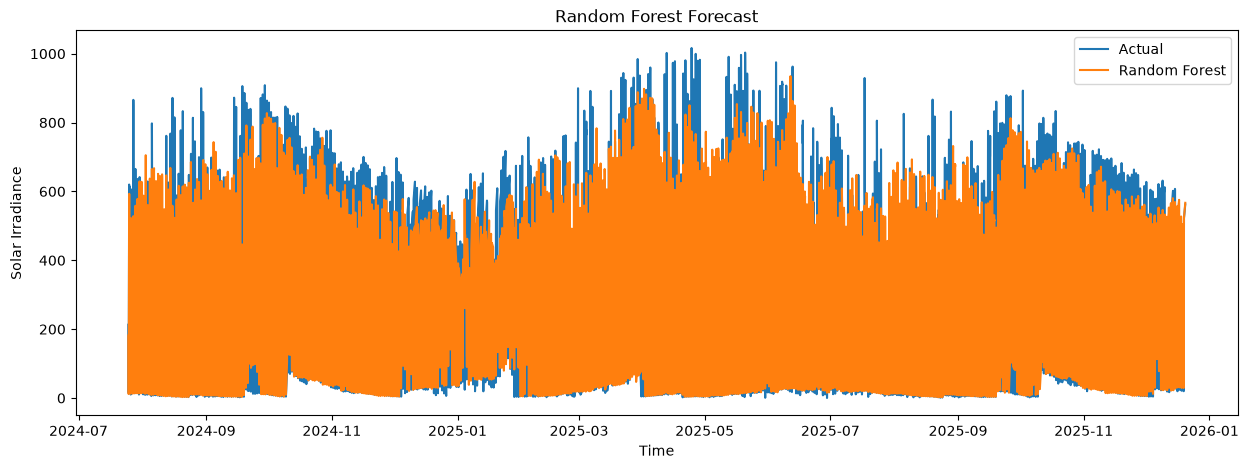

In [225]:
plt.figure(figsize=(15,5))

plt.plot(y_test.index, y_test, label="Actual")
plt.plot(y_test.index, rf_pred, label="Random Forest")

plt.title("Random Forest Forecast")
plt.xlabel("Time")
plt.ylabel("Solar Irradiance")

plt.legend()

plt.show()

In [226]:
# <--------------------------------------- VAR ------------------------------------------------>

In [227]:
forecast_horizon = 1

temp = df.copy()

temp["target"] = temp["ALLSKY_SFC_SW_DWN"].shift(-forecast_horizon)

temp = temp.dropna()

In [228]:
var_df = temp[
    [
        "target",
        "T2M",
        "RH2M",
        "PS",
        "WS10M"
    ]
]

In [229]:
train_size = int(len(var_df) * 0.8)

train = var_df.iloc[:train_size]

test = var_df.iloc[train_size:]

In [230]:
model = VAR(train)

model_fit = model.fit(maxlags=24)

lag_order = model_fit.k_ar

forecast = model_fit.forecast(
    train.values[-lag_order:],
    steps=len(test)
)

forecast_df = pd.DataFrame(
    forecast,
    columns=train.columns,
    index=test.index
)


/Users/ak/Desktop/projects/DL_wind_solar_forecast/tf_env/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [231]:
var_pred = forecast_df["target"]

mae = mean_absolute_error(
    test["target"],
    var_pred
)

rmse = np.sqrt(
    mean_squared_error(
        test["target"],
        var_pred
    )
)

r2 = r2_score(
    test["target"],
    var_pred
)

print("1 Hour")
print(mae)
print(rmse)
print(r2)

results.append({
    "MODEL":"VAR",
    "Horizon": "1h",
    "MAE": mae,
    "RMSE": rmse,
    "R2": r2
})

1 Hour
216.43405381837042
250.58119129928033
-0.0048707862209929065


In [232]:
forecast_horizon = 6

temp = df.copy()

temp["target"] = temp["ALLSKY_SFC_SW_DWN"].shift(-forecast_horizon)

temp = temp.dropna()

var_df = temp[
    [
        "target",
        "T2M",
        "RH2M",
        "PS",
        "WS10M"
    ]
]

train_size = int(len(var_df) * 0.8)

train = var_df.iloc[:train_size]

test = var_df.iloc[train_size:]

model = VAR(train)

model_fit = model.fit(maxlags=24)

lag_order = model_fit.k_ar

forecast = model_fit.forecast(
    train.values[-lag_order:],
    steps=len(test)
)

forecast_df = pd.DataFrame(
    forecast,
    columns=train.columns,
    index=test.index
)

var_pred = forecast_df["target"]

mae = mean_absolute_error(
    test["target"],
    var_pred
)

rmse = np.sqrt(
    mean_squared_error(
        test["target"],
        var_pred
    )
)

r2 = r2_score(
    test["target"],
    var_pred
)

print("6 Hour")
print(mae)
print(rmse)
print(r2)

results.append({
    "MODEL":"VAR",
    "Horizon": "6h",
    "MAE": mae,
    "RMSE": rmse,
    "R2": r2
})


/Users/ak/Desktop/projects/DL_wind_solar_forecast/tf_env/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


6 Hour
216.6109353286917
250.73525144027806
-0.005955693276242124


In [233]:
forecast_horizon = 12

temp = df.copy()

temp["target"] = temp["ALLSKY_SFC_SW_DWN"].shift(-forecast_horizon)

temp = temp.dropna()

var_df = temp[
    [
        "target",
        "T2M",
        "RH2M",
        "PS",
        "WS10M"
    ]
]

train_size = int(len(var_df) * 0.8)

train = var_df.iloc[:train_size]

test = var_df.iloc[train_size:]

model = VAR(train)

model_fit = model.fit(maxlags=24)

lag_order = model_fit.k_ar

forecast = model_fit.forecast(
    train.values[-lag_order:],
    steps=len(test)
)

forecast_df = pd.DataFrame(
    forecast,
    columns=train.columns,
    index=test.index
)

var_pred = forecast_df["target"]

mae = mean_absolute_error(
    test["target"],
    var_pred
)

rmse = np.sqrt(
    mean_squared_error(
        test["target"],
        var_pred
    )
)

r2 = r2_score(
    test["target"],
    var_pred
)

print("12 Hour")
print(mae)
print(rmse)
print(r2)


results.append({
    "MODEL":"VAR",
    "Horizon": "12h",
    "MAE": mae,
    "RMSE": rmse,
    "R2": r2
})


/Users/ak/Desktop/projects/DL_wind_solar_forecast/tf_env/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


12 Hour
215.9991245964362
250.13843135432546
-0.0010429005509087208


In [234]:
forecast_horizon = 24

temp = df.copy()

temp["target"] = temp["ALLSKY_SFC_SW_DWN"].shift(-forecast_horizon)

temp = temp.dropna()

var_df = temp[
    [
        "target",
        "T2M",
        "RH2M",
        "PS",
        "WS10M"
    ]
]

train_size = int(len(var_df) * 0.8)

train = var_df.iloc[:train_size]

test = var_df.iloc[train_size:]

model = VAR(train)

model_fit = model.fit(maxlags=24)

lag_order = model_fit.k_ar

forecast = model_fit.forecast(
    train.values[-lag_order:],
    steps=len(test)
)

forecast_df = pd.DataFrame(
    forecast,
    columns=train.columns,
    index=test.index
)

var_pred = forecast_df["target"]

mae = mean_absolute_error(
    test["target"],
    var_pred
)

rmse = np.sqrt(
    mean_squared_error(
        test["target"],
        var_pred
    )
)

r2 = r2_score(
    test["target"],
    var_pred
)

print("24 Hour")
print(mae)
print(rmse)
print(r2)

results.append({
    "MODEL":"VAR",
    "Horizon": "24h",
    "MAE": mae,
    "RMSE": rmse,
    "R2": r2
})


/Users/ak/Desktop/projects/DL_wind_solar_forecast/tf_env/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


24 Hour
214.72072219477263
249.1065095230993
0.007082535398546863


In [235]:
# ---------------------- XGBoost ----------------------

results.append({
    "MODEL": "XGBoost",
    "Horizon": "1h",
    "MAE": 25.452072,
    "RMSE": 38.073491,
    "R2": 0.976635
})

results.append({
    "MODEL": "XGBoost",
    "Horizon": "6h",
    "MAE": 64.487104,
    "RMSE": 91.657339,
    "R2": 0.864640
})

results.append({
    "MODEL": "XGBoost",
    "Horizon": "12h",
    "MAE": 78.520172,
    "RMSE": 112.068637,
    "R2": 0.797586
})

results.append({
    "MODEL": "XGBoost",
    "Horizon": "24h",
    "MAE": 93.879697,
    "RMSE": 127.821954,
    "R2": 0.736662
})


# ---------------------- Hybrid (XGBoost + LSTM) ----------------------

results.append({
    "MODEL": "Hybrid (XGBoost + LSTM)",
    "Horizon": "1h",
    "MAE": 44.58425845427537,
    "RMSE": 59.29119145185148,
    "R2": 0.9434055225434014
})

In [236]:
results = pd.DataFrame(results)

print(results) 

                      MODEL Horizon         MAE        RMSE        R2
0                     ARIMA      1h  213.938492  249.507715 -0.003642
1                     ARIMA      6h  213.917955  249.475199 -0.003505
2                     ARIMA     12h  213.962927  249.996231 -0.007186
3                     ARIMA     24h  214.808485  249.224699 -0.000626
4                   SARIMAX      1h  505.362481  594.330059 -4.684740
5                   SARIMAX      6h  388.371371  470.543433 -2.563248
6                   SARIMAX     12h  636.790522  725.163266 -7.458100
7                   SARIMAX     24h  244.161689  289.000288 -0.340692
8             RANDOM FOREST      1h   23.448250   37.766668  0.977114
9             RANDOM FOREST      6h   60.189322   93.622822  0.859361
10            RANDOM FOREST     12h   74.838116  112.222513  0.798025
11            RANDOM FOREST     24h   85.492128  124.725488  0.750617
12                      VAR      1h  216.434054  250.581191 -0.004871
13                  

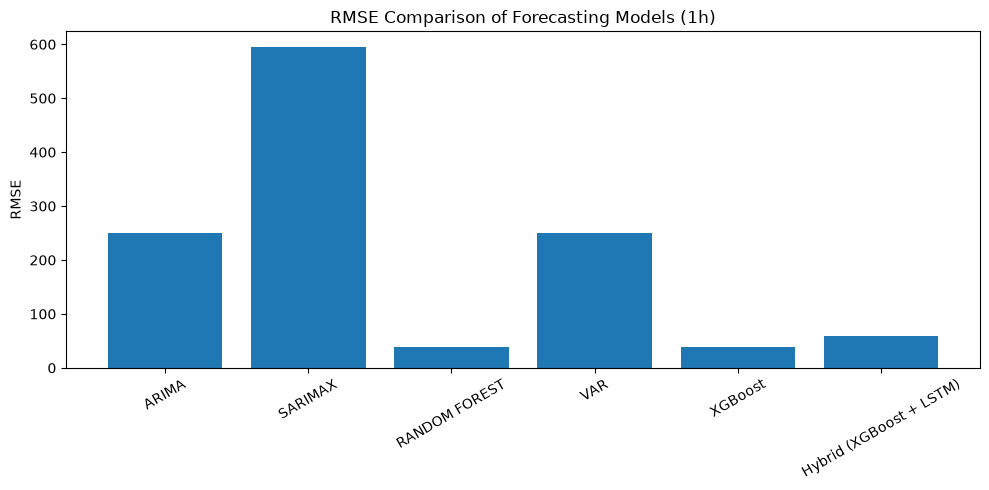

In [237]:
import matplotlib.pyplot as plt

comparison = results[results["Horizon"]=="1h"]

plt.figure(figsize=(10,5))
plt.bar(comparison["MODEL"], comparison["RMSE"])
plt.xticks(rotation=30)
plt.ylabel("RMSE")
plt.title("RMSE Comparison of Forecasting Models (1h)")
plt.tight_layout()
plt.show()

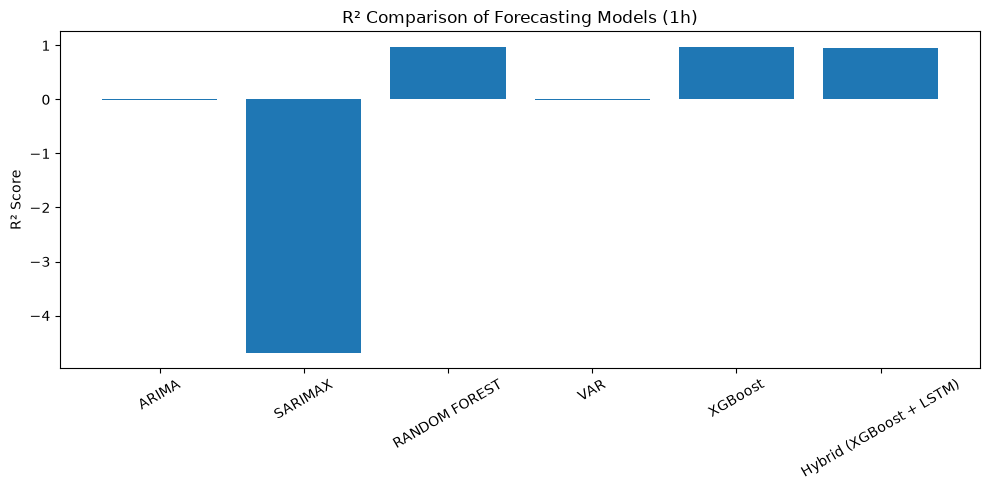

In [238]:
comparison = results[results["Horizon"]=="1h"]

plt.figure(figsize=(10,5))
plt.bar(comparison["MODEL"], comparison["R2"])
plt.xticks(rotation=30)
plt.ylabel("R² Score")
plt.title("R² Comparison of Forecasting Models (1h)")
plt.tight_layout()
plt.show()